**Week 2 SBI library + experiments** \
Date: 25/07/09 \
Objectives:
- SBI library explorations 
    - Amortised NPE and multi-round NPE
    - Embedding network
    - Sampling
- Fisher Information calculation implement

**SBI lib explorations** \
following official sbi documentations, cont. from week 1

**Amortised NPE**  \
The two sets of data simulated with distinct parameters $\theta$ both evaluated and plotted to show the posteriors are evaluated well enough to indicate where the 'true parameter' (in this case sampled from the prior rather than a real theoretical value). Using amortised inference network allows fast evaluation of different observational data even those not used for training the network to begin with, as long as the prior and simulator remain the same for the new data, therefore reducing computational cost for future data processing.

In [29]:
#Amortised Gaussian, training stage
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi import analysis as analysis
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

#Define the simulator and prior
num_dim = 3
def simulator(theta):
    #simulated data from a gaussian noise
    return theta + torch.randn_like(theta) * 0.1 + 1  

prior = utils.BoxUniform(-2*torch.ones(num_dim),2*torch.ones(num_dim))

#check simulated data and prior inputs
simulator, prior = prepare_for_sbi(simulator, prior)

#inference
inference = SNPE(prior=prior)
num_sim = 10000

#simulations
theta = prior.sample((num_sim,))
x = simulator(theta)
inference = inference.append_simulations(theta, x)

density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 64 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

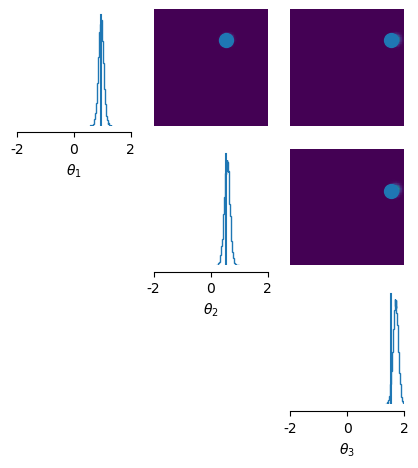

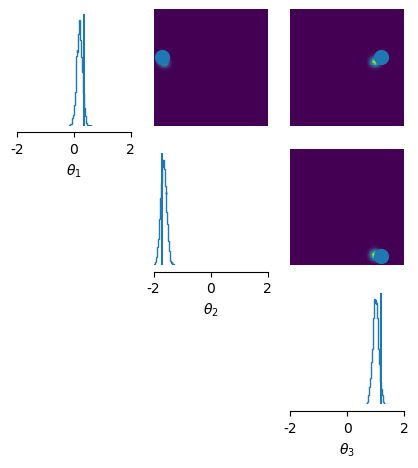

In [30]:
#Applying two sets of distinct observations
theta_1 = prior.sample((1,))
xobs_1 = simulator(theta_1)

theta_2 = prior.sample((1,))
xobs_2 = simulator(theta_2)

#without running twice the inference step, we can generate two sets of 'observed' data, xobs_1 and xobs_2
#and evaluate posteriors given the two parameters theta_1 and theta_2

posterior_samples_1 = posterior.sample((10000,), x=xobs_1)

#plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_1
)

posterior_samples_2 = posterior.sample((10000,), x=xobs_2)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_2, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_2
)

**Multi-round NPE** \
used when interested in very few number of sets of observational data, therefore can train the network multiple times to get a better posterior estimation. \
Process goes: prior+simulator --> posterior + simulated data from data --> input simulated data to train posterior again --> draw more data from the new posterior--> train posterior again... until a desired accuracy is achieved.

In [31]:
#use the same prior and simulator models from before
num_dim=3

def simulator(theta):
    #simulated data from a gaussian noise
    return theta + torch.randn_like(theta) * 0.1 + 1  

prior = utils.BoxUniform(-2*torch.ones(num_dim),2*torch.ones(num_dim))

#check simulated data and prior inputs
simulator, prior = prepare_for_sbi(simulator, prior)

#inference
inference = SNPE(prior=prior)
num_sim = 500

num_rounds = 2 #train two rounds

x_o = torch.zeros(num_dim,)  #infer the posterior around this 'observation' point, ie conditioning on this data
#will cause different outcomes of posterior if conditioned on different x_o

posteriors = [] #initialise posterior
proposal = prior #initialise proposal distribution to be the prior 
thetas = []

for _ in range(num_rounds):
    theta, xobs = simulate_for_sbi(simulator=simulator, proposal=proposal, num_simulations=500)
    inference = inference.append_simulations(theta, xobs, proposal=proposal)  #simulate and train the model based on the proposal function 
    #which will be updated at the end of loop
    density_estimator = inference.train()
    posterior = inference.build_posterior(density_estimator)
    posteriors.append(posterior)
    proposal = posterior.set_default_x(x_o)  #update proposal for the next round as posterior estimated
    #new data is then simulated from the posterior
    thetas.append(theta)

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 104 epochs.

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 21 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

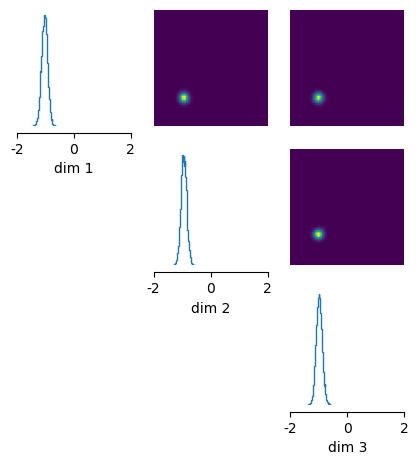

In [32]:
#visualisation
posterior_samples = posterior.sample((10000,), x=x_o)

_ = analysis.pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5)
)

**Fisher Information calculation** \
Fisher information is defined as the variance of the gradient of log likelihood, which quantifies the 'amount' of information of the true parameter (eg. a mean) carried by a distribution that models the observed sample. For dimensions higher than 1D, it takes a DxD matrix form that includes covariance between variables of the multi-variable distribution.

Fisher information from sample set 1 =0.8684508948997302, from set 2 =0.6544568478418697, from set 3 =1.1194562897966476


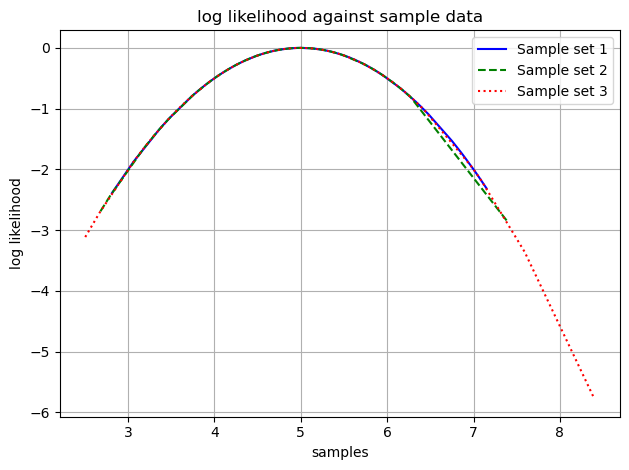

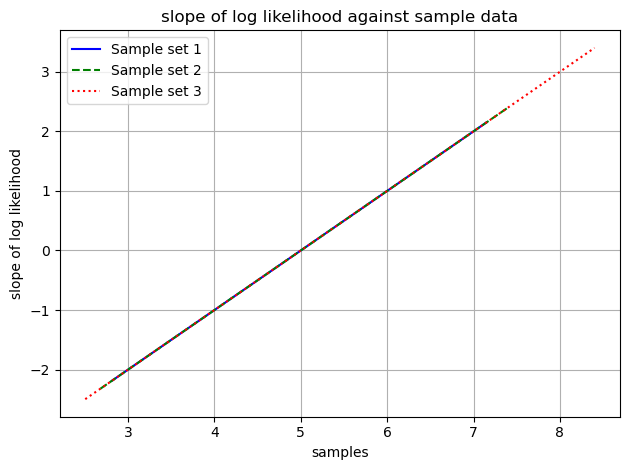

In [33]:
#1D example
# plan is to generate several random distribution of sample points from the true mu distribution 
# and calculate Fisher information of each sample sets and find the one sample set that best resembles the true distribution 
import numpy as np
import matplotlib.pyplot as plt
import torch
np.random.seed(13)

true_mu = 5
true_sd = 1

def log_likelihood(mu, sd, sample):
    ll = []
    for data in sample:
        ll.append(-0.5 * (data - mu)**2 / (sd**2))
    return ll

def slope_ll(mu, sd, sample):  #slope of log likelihood function wrt parameter mu
    slope = []
    for data in sample:
        slope.append( (data - mu) / (sd**2))
    return slope

#take 3 x 100 random sample points from the true distribution
sample1 = np.sort(np.random.normal(true_mu, true_sd, size=100))
sample2 = np.sort(np.random.normal(true_mu, true_sd, size=100)) 
sample3 = np.sort(np.random.normal(true_mu, true_sd, size=100))

FI1 = np.var(slope_ll(true_mu, true_sd, sample1))
FI2 = np.var(slope_ll(true_mu, true_sd, sample2))
FI3 = np.var(slope_ll(true_mu, true_sd, sample3))
print(f'Fisher information from sample set 1 ={FI1}, from set 2 ={FI2}, from set 3 ={FI3}')

plt.figure()
plt.plot(sample1, log_likelihood(true_mu, true_sd, sample1), label='Sample set 1', color='blue', linestyle='-')
plt.plot(sample2, log_likelihood(true_mu, true_sd, sample2), label='Sample set 2', color='green', linestyle='--')
plt.plot(sample3, log_likelihood(true_mu, true_sd, sample3), label='Sample set 3', color='red', linestyle=':')
plt.xlabel('samples')
plt.ylabel('log likelihood')
plt.title('log likelihood against sample data')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.figure()
plt.plot(sample1, slope_ll(true_mu, true_sd, sample1), label='Sample set 1', color='blue', linestyle='-')
plt.plot(sample2, slope_ll(true_mu, true_sd, sample2), label='Sample set 2', color='green', linestyle='--')
plt.plot(sample3, slope_ll(true_mu, true_sd, sample3), label='Sample set 3', color='red', linestyle=':')
plt.xlabel('samples')
plt.ylabel('slope of log likelihood')
plt.title('slope of log likelihood against sample data')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.show()


In this trial even though the 3 sample sets of data produced (seemingly) perfectly overlapping log likelihood and score function, their respective Fisher information came out to be different, this is expected as the sample size (=100) is not sufficiently large to cancel out the naturally occuring noise in random sampling and that the Fisher information is very sensitive to small differences between points. Had the sample size be sufficiently large the FI's could converge better.

Fisher information from sample set 1 =0.890497588499562, from set 2 =1.000130416451432, from set 3 =1.0009170202653195, 
better convergence seen with large sample sizes!


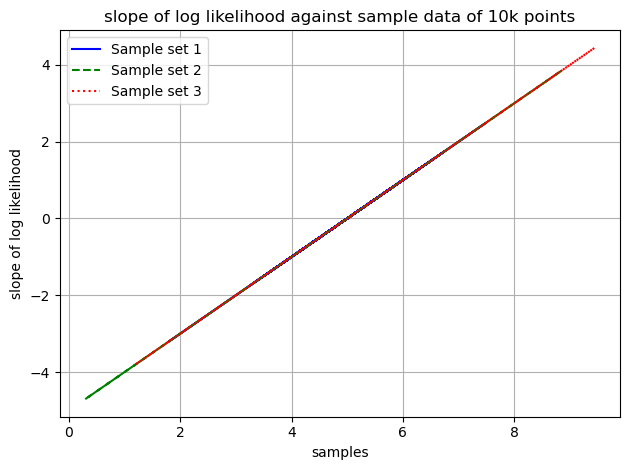

In [34]:
#take one 100 and 2x 10000 random sample points from the true distribution
sample1 = np.random.normal(true_mu, true_sd, size=100)  #size = 100
sample2 = np.random.normal(true_mu, true_sd, size=10000)  #size = 10000 
sample3 = np.random.normal(true_mu, true_sd, size=10000) 

FI1 = np.var(slope_ll(true_mu, true_sd, sample1))
FI2 = np.var(slope_ll(true_mu, true_sd, sample2))
FI3 = np.var(slope_ll(true_mu, true_sd, sample3))
print(f'Fisher information from sample set 1 ={FI1}, from set 2 ={FI2}, from set 3 ={FI3}, \n'
      'better convergence seen with large sample sizes!')

plt.figure()
plt.plot(sample1, slope_ll(true_mu, true_sd, sample1), label='Sample set 1', color='blue', linestyle='-')
plt.plot(sample2, slope_ll(true_mu, true_sd, sample2), label='Sample set 2', color='green', linestyle='--')
plt.plot(sample3, slope_ll(true_mu, true_sd, sample3), label='Sample set 3', color='red', linestyle=':')
plt.xlabel('samples')
plt.ylabel('slope of log likelihood')
plt.title('slope of log likelihood against sample data of 10k points')
plt.legend()
plt.tight_layout()
plt.grid(True)

plt.show()

**Embedding space** \
Embedding networks can reduce the dimensionality of data to a learned low-D vector representation based on certain charateristics of the sample data. The network converts input into a d-dimensional vector and similar items will have a short (Euclidean) distance between their positions in the embedding space.\
It's different to latent space (and embedding vectors different to latent variables) in the sense that latent space acccounts for implicit hiddent causes that affect the output (or have certain physical meanings), whereas embedding space is a vector space with arbitrarily defined basis, such the characteristics of the input are 'embedded' into the basis vectors. \
Embedding networks are optimised for simularity-distance (eg. if we train a network with defined 'similar' items and require a small distance between their vectors)

Text(0.5, 1.0, 'noisy observed data (gray image with 32 x 32 pixels)')

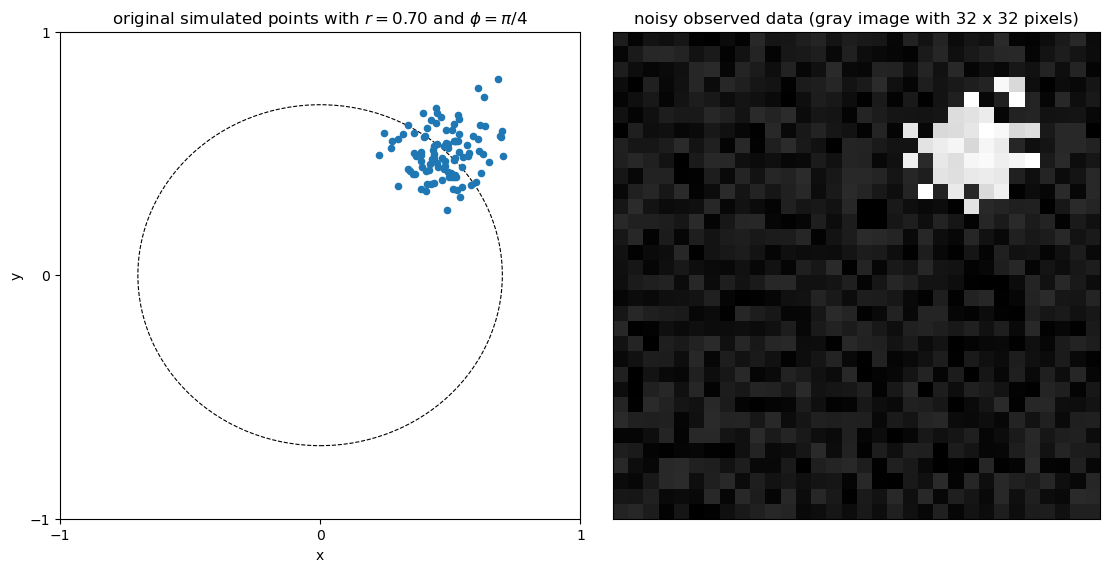

In [1]:
# example of using embedding_net (CNN here) to learn summary statistics from simulation outputs (with NPE or NRE)
# compare with previous NPE inference, the simulated data in the embedding network example passes through the embedding_net 
# before being used to train NPE

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sbi import analysis, utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

seed = 0
torch.manual_seed(seed)

#define the simulator model for data simulation
def simulator(parameter, return_points=False):
    # 2D parameter, generate (rcos(phi), rsin(phi)) + Gaussian noise
    # then generate a 32x32 greyscale image
    r = parameter[0]
    phi = parameter[1]
    sd_points = 0.1
    npoints = 100
    points = []

    for _ in range(npoints):
        x = r * torch.cos(phi) + torch.randn(1) * sd_points
        y = r * torch.sin(phi) + torch.randn(1) * sd_points
        points.append([x,y])  #append the output coordinates then create a torch tensor for image creation
    points = torch.as_tensor(points)

    nx, ny = 32, 32   #image shape
    sd_image = 0.2   #uniform noise between 0 and 0.2
    im = torch.zeros(nx, ny)   #storing greyscale of each pixel, the 'observed data'
    for point in points:
        pi = int((point[0] - (-1)) / ((+1) - (-1)) * nx)
        pj = int((point[1] - (-1)) / ((+1) - (-1)) * ny)  #rescale coordinates to betwee 0 and 1
        if (pi < nx) and (pj < ny):  #prevents index out of bound
            im[pi, pj] = 1  #mark pixel as 1 at the point's location

    im = im + sd_image * torch.rand(nx, ny)  #add noise to the greyscale representation
    im = im.T
    im = im.reshape(1, -1)  #converts to flat vector (1, 1024)

    if return_points:
        return im, points
    else:
        return im
    
#true parameters
r, phi = 0.7, torch.pi/4
true_parameter = torch.tensor([r, phi])
x_obs, x_points = simulator(true_parameter, return_points=True)

#plot
fig, ax = plt.subplots(
    facecolor="white", figsize=(11.15, 5.61), ncols=2, constrained_layout=True
)
circle = plt.Circle((0, 0), radius=r, color="k", ls="--", lw=0.8, fill=False)
ax[0].add_artist(circle)
ax[0].scatter(x_points[:, 0], x_points[:, 1], s=20)
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_xlim(-1, +1)
ax[0].set_xticks([-1, 0.0, +1.0])
ax[0].set_ylim(-1, +1)
ax[0].set_yticks([-1, 0.0, +1.0])
ax[0].set_title(r"original simulated points with $r = 0.70$ and $\phi = \pi/4$")
ax[1].imshow(x_obs.view(32, 32), origin="lower", cmap="gray")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("noisy observed data (gray image with 32 x 32 pixels)")


In [6]:
#use CNN to learn summary stats from the simulated data, reduce the high dimensionality of original data (=1024)

from sbi.neural_nets.embedding_nets import CNNEmbedding
from sbi.inference import simulate_for_sbi, prepare_for_sbi
from sbi.utils import posterior_nn

embedding_net = CNNEmbedding(
    input_shape=(32, 32),
    in_channels=1,
    out_channels_per_layer=[6],
    num_conv_layers=1,
    num_linear_layers=1,
    output_dim=8,
    kernel_size=5,
    pool_kernel_size=8
)

#construct the neural network training 
prior = utils.BoxUniform(low=torch.tensor([0,0]), high=torch.tensor([1, 2*torch.pi]))
simulator, prior = prepare_for_sbi(simulator, prior)

neural_posterior = posterior_nn(model='maf', embedding_net=embedding_net)

inference = SNPE(prior=prior, density_estimator=neural_posterior)
theta, x = simulate_for_sbi(simulator, prior, num_simulations=10000)  #same as calling theta=prior.sample() and x=simulator()

density_estimator = inference.append_simulations(theta, x).train(training_batch_size=256)
posterior = inference.build_posterior(density_estimator)

Running 10000 simulations.:   0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 106 epochs.

Drawing 50000 posterior samples:   0%|          | 0/50000 [00:00<?, ?it/s]

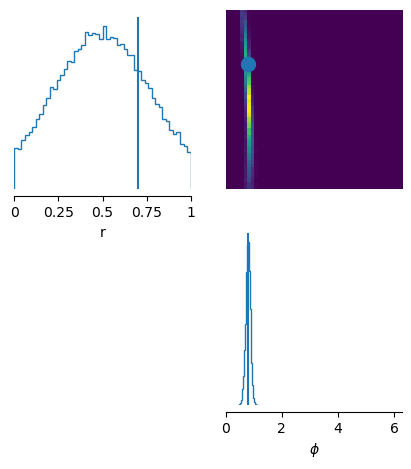

In [11]:
#generate posterior samples
true_parameter = torch.tensor([[r, phi]])
x_observed = simulator(true_parameter)
samples = posterior.set_default_x(x_observed).sample((50000,))

#create the figure
fig, ax = analysis.pairplot(
    samples,
    points=true_parameter,
    labels=["r", r"$\phi$"],
    limits=[[0, 1], [0, 2 * torch.pi]],
    fig_kwargs=dict(
        points_colors="r",
        points_offdiag={"markersize": 6},
    ),
    figsize=(5, 5),
)

**Sampling** \
In sbi the posterior is directly approximated by the neural network therefore sampling from the neural network gives samples from the posterior approximated.